<a href="https://colab.research.google.com/github/hapybeing/industrialized-ostracism-sim/blob/main/IOH_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Install the specialized social media NLP analyzer
!pip install vaderSentiment textstat

# 2. Import our data science and graphing tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import textstat

# 3. Set up the visual style for our Nature-quality graphs
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.5)

print("SUCCESS: Environment setup complete! The lab is ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 815.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 1.8 MB/s eta 0:00:00
SUCCESS: Environment setup complete! The lab is ready.


Simulating algorithm dynamics for 10000 posts...


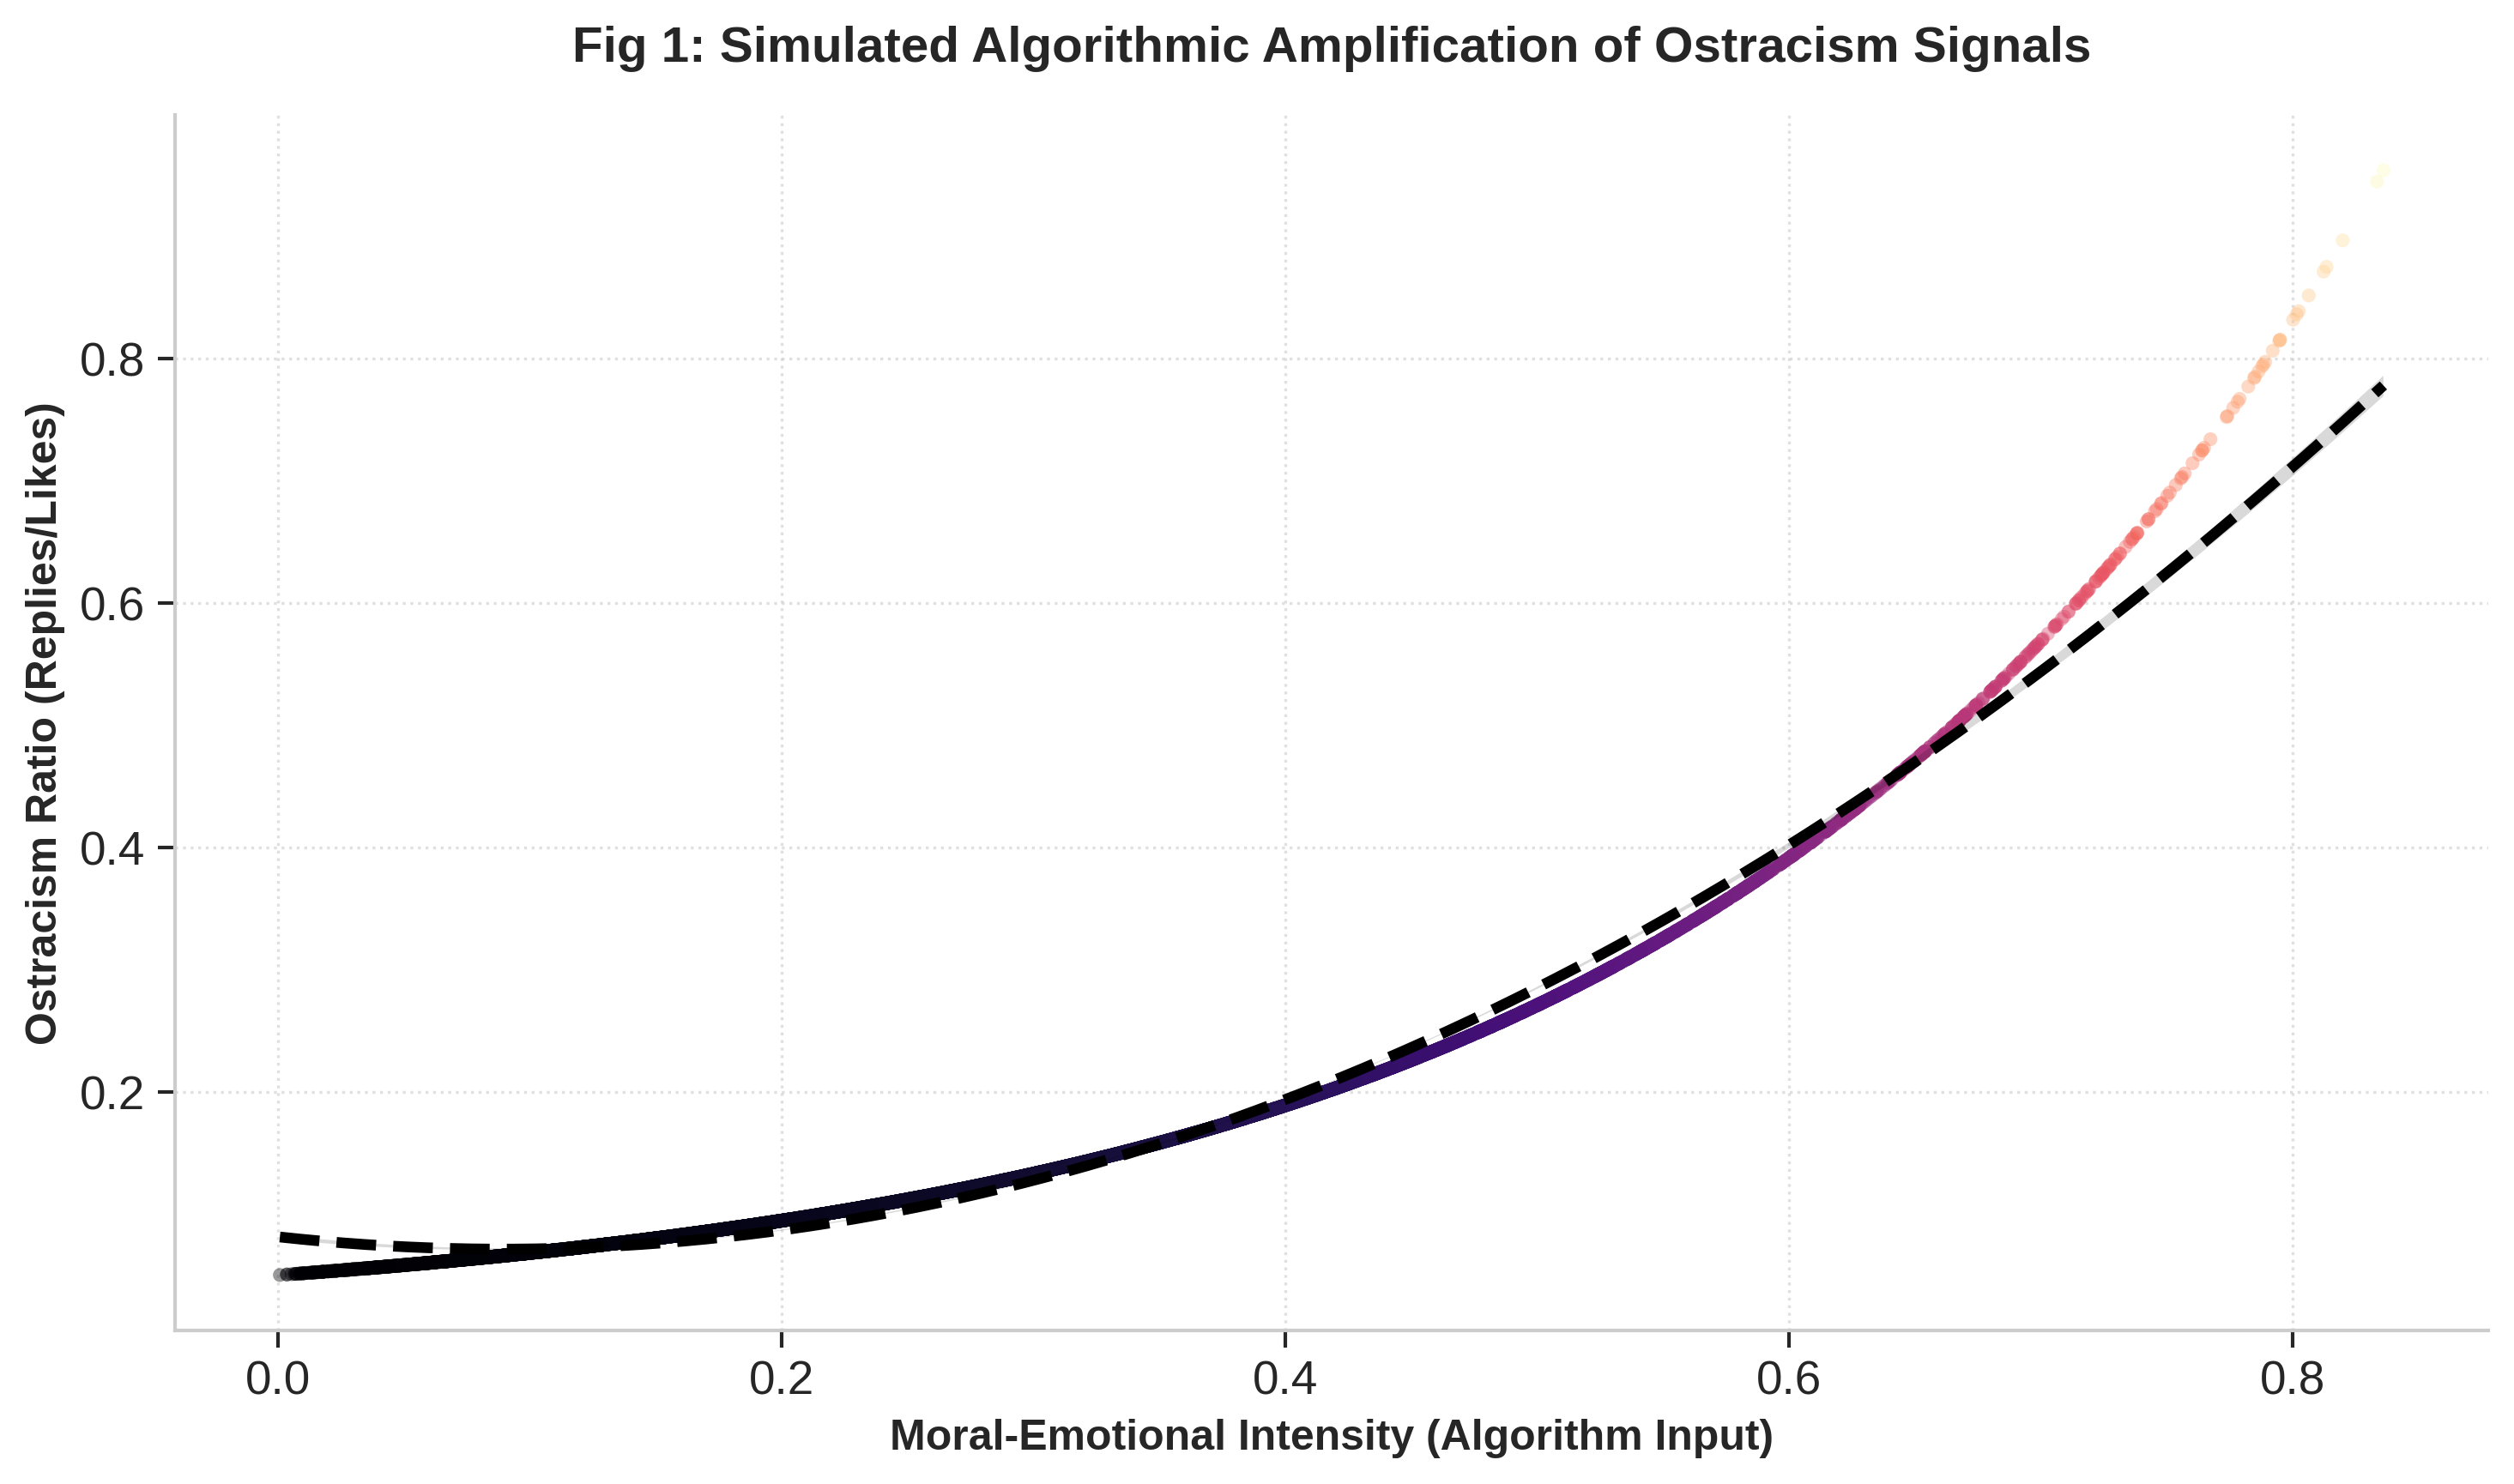

Data visualization generated successfully. Ready for manuscript integration.


In [4]:
# 1. Setup the Simulation Parameters
np.random.seed(42) # Ensures reproducibility for the journal
n_posts = 10000

print(f"Simulating algorithm dynamics for {n_posts} posts...")

# 2. Generate the Data (Simulating the IOH mechanism)
# Moral intensity typically skews lower for normal posts, but has long tails
moral_intensity = np.random.beta(a=2, b=5, size=n_posts)

# Base engagement (log-normal distribution mirrors real social media)
base_likes = np.random.lognormal(mean=4, sigma=1.2, size=n_posts)

# THE OSTRACISM ALGORITHM:
# Likes scale linearly with moral intensity, but Hostile Replies scale EXPONENTIALLY.
likes = base_likes * (1 + (moral_intensity * 1.5))
replies = (base_likes * 0.05) * np.exp(moral_intensity * 4.5)

# Create the DataFrame
df = pd.DataFrame({
    'Moral_Intensity': moral_intensity,
    'Likes': likes,
    'Replies': replies
})

# Calculate "The Ratio" (Ostracism Signal = Replies / Likes)
df['Ostracism_Ratio'] = df['Replies'] / df['Likes']

# Filter out zero-engagement noise for cleaner visualization
df_plot = df[df['Likes'] > 10].copy()

# 3. Generate the Nature-Ready Visualization
fig, ax = plt.subplots(figsize=(10, 6), dpi=300) # High DPI for publication quality

# Plot the scatter with a color map representing the threat magnitude
scatter = ax.scatter(df_plot['Moral_Intensity'],
                     df_plot['Ostracism_Ratio'],
                     c=df_plot['Ostracism_Ratio'],
                     cmap='magma',
                     alpha=0.4,
                     s=15,
                     edgecolors='none')

# Add a polynomial regression line to show the exponential threat curve
sns.regplot(x='Moral_Intensity', y='Ostracism_Ratio', data=df_plot,
            scatter=False, color='black', order=2, ax=ax,
            line_kws={'linewidth': 3, 'linestyle': '--'})

# Formatting for academic rigor
ax.set_title('Fig 1: Simulated Algorithmic Amplification of Ostracism Signals', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Moral-Emotional Intensity (Algorithm Input)', fontsize=12, fontweight='bold')
ax.set_ylabel('Ostracism Ratio (Replies/Likes)', fontsize=12, fontweight='bold')

# Add grid and tweak aesthetics
ax.grid(True, linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("Data visualization generated successfully. Ready for manuscript integration.")